In [32]:
import mne
import pandas as pd
import numpy as np
import os
import warnings
from pathlib import Path
from typing import Union
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import random
import matplotlib.pyplot as plt
import pprint
import re

In [4]:
mne.set_log_level('ERROR')
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [30]:
def simplificar_estructura(root_dir):
    root = Path(root_dir)
    print(f"📂 Iniciando limpieza en: {root}")

    # 1. Primero renombramos las carpetas de sesiones (Nivel más profundo)
    # Buscamos todas las carpetas que contienen '='
    folders_with_equal = sorted(list(root.rglob("*=*")), key=lambda x: len(x.parts), reverse=True)
    
    renamed_count = 0
    
    for folder in folders_with_equal:
        if folder.is_dir():
            # Extraemos lo que hay después del '='
            # Ejemplo: 'session=s002_2011' -> 's002_2011'
            new_name = folder.name.split("=")[-1]
            new_path = folder.parent / new_name
            
            try:
                # Verificamos si la carpeta de destino ya existe para evitar colisiones
                if not new_path.exists():
                    folder.rename(new_path)
                    renamed_count += 1
                else:
                    # Si ya existe (ej. por un error previo), movemos los archivos y borramos la vieja
                    for file in folder.iterdir():
                        dest_file = new_path / file.name
                        if not dest_file.exists():
                            file.rename(dest_file)
                    folder.rmdir()
                    renamed_count += 1
            except Exception as e:
                print(f"❌ No se pudo renombrar {folder.name}: {e}")

    print(f"✅ Limpieza completada. Se reestructuraron {renamed_count} carpetas.")
    print(f"Nueva estructura: {root.name}/[ID_PACIENTE]/[ID_SESION]/[ARCHIVO].parquet")

In [6]:
CLEAN_DATA_DIR = r"D:\TUSZ_DataLake\03_TUSZ_Clean"
simplificar_estructura(CLEAN_DATA_DIR)

📂 Iniciando limpieza en: D:\TUSZ_DataLake\03_TUSZ_Clean
✅ Limpieza completada. Se reestructuraron 2317 carpetas.
Nueva estructura: 03_TUSZ_Clean/[ID_PACIENTE]/[ID_SESION]/[ARCHIVO].parquet


In [31]:
def get_detailed_metadata(edf_path):
    # Leer header de forma ligera
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
    
    # 1. Extraer del Header Crudo (Edad y campos originales)
    with open(edf_path, 'rb') as f:
        raw_header = f.read(256).decode('ascii', errors='ignore')
        patient_field = raw_header[8:88].strip()
        record_field = raw_header[88:168].strip()

    # Regex para la edad (es lo único que no suele venir estructurado en MNE)
    age_match = re.search(r'Age:(\d+)', patient_field)
    age = age_match.group(1) if age_match else "N/A"

    # 2. Consolidar Metadata
    metadata = {
        "file_name": Path(edf_path).name,
        "patient_id": raw.info['subject_info']['his_id'] if raw.info['subject_info'] else "Unknown",
        "gender_coded": raw.info['subject_info']['sex'] if raw.info['subject_info'] else "Unknown",
        "age": age,
        "sfreq": raw.info['sfreq'],
        "nchan": raw.info['nchan'],
        "meas_date": str(raw.info['meas_date']),
        "patient_field_raw": patient_field,
        "record_field_raw": record_field,
        "highpass": raw.info['highpass'],
        "lowpass": raw.info['lowpass']
    }
    
    return metadata

In [35]:
def normalize_channels(raw: mne.io.Raw, sfreq_target: float = 250.0) -> mne.io.Raw:
    """Estandariza nomenclatura, selecciona 10-20 y remuestrea."""
    # 1. Limpieza de etiquetas
    base_mapping = {ch: ch.replace('EEG ', '').replace('-REF', '').replace('-LE', '').strip() 
                    for ch in raw.ch_names}
    
    # 2. Diccionario de correcciones
    corrections = {'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz'}
    final_mapping = {k: corrections.get(v.upper(), v) for k, v in base_mapping.items()}
    
    raw.rename_channels(final_mapping, verbose=False)
    
    # 3. Selección Sistema 10-20
    standard_1020 = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
                     'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
    
    existing_channels = [ch for ch in standard_1020 if ch in raw.ch_names]
    raw.pick(existing_channels, verbose=False)
    
    if raw.info['sfreq'] != sfreq_target:
        raw.resample(sfreq_target, n_jobs=1, verbose=False)
    return raw


In [38]:
def apply_clinical_filters(raw: mne.io.Raw) -> mne.io.Raw:
    """Filtros de fase cero: Notch (60Hz) y Pasa-Banda (0.5-80Hz)."""
    raw.notch_filter(freqs=60.0, notch_widths=2.0, method='iir', 
                     phase='zero', n_jobs=1, verbose=False)
    
    filter_params = dict(order=8, ftype='butter', output='sos')
    raw.filter(l_freq=0.5, h_freq=80.0, method='iir', 
               iir_params=filter_params, phase='zero', n_jobs=1, verbose=False)
    return raw

In [44]:
def apply_longitudinal_bipolar_montage(raw: mne.io.Raw) -> mne.io.Raw:
    """Montaje Bipolar Longitudinal (Double Banana)."""
    pairs = [
        ('Fp1', 'F7'), ('F7', 'T3'), ('T3', 'T5'), ('T5', 'O1'),
        ('Fp2', 'F8'), ('F8', 'T4'), ('T4', 'T6'), ('T6', 'O2'),
        ('Fp1', 'F3'), ('F3', 'C3'), ('C3', 'P3'), ('P3', 'O1'),
        ('Fp2', 'F4'), ('F4', 'C4'), ('C4', 'P4'), ('P4', 'O2'),
        ('Fz', 'Cz'), ('Cz', 'Pz')
    ]
    
    current_channels = raw.ch_names
    valid_pairs = [(a, c) for a, c in pairs if a in current_channels and c in current_channels]
    
    anodes = [p[0] for p in valid_pairs]
    cathodes = [p[1] for p in valid_pairs]
    new_ch_names = [f"{p[0]}-{p[1]}" for p in valid_pairs]

    return mne.set_bipolar_reference(raw, anode=anodes, cathode=cathodes, 
                                     ch_name=new_ch_names, drop_refs=True, verbose=False)

# Manual clean

In [24]:
id_buscado = "aaaaaqtl"
resultado = df_pacientes[df_pacientes['patient_id'] == id_buscado]

# 6. Mostrar el resultado
if not resultado.empty:
    print(f"🔍 Se encontró información para el paciente: {id_buscado}")
    display(resultado)
else:
    print(f"⚠️ No se encontró ningún registro para el ID: {id_buscado}")

🔍 Se encontró información para el paciente: aaaaaqtl


,patient_num_id,patient_id,original_split,age,gender,n_sessions,total_duration_sec,split_final
299,300,aaaaaqtl,train,64,2,3,37384.0,0


In [28]:
edf_path = Path(r"D:\TUSZ_DataLake\01_Raw_Consolidated\aaaaaqtl\s011_2014\aaaaaqtl_s011_t004.edf")
output_dir = Path(r"D:\TUSZ_DataLake\03_TUSZ_Clean\300\s011_2014")

In [33]:
info_completa = get_detailed_metadata(edf_path)
pprint.pprint(info_completa)

{'age': '53',
 'file_name': 'aaaaaqtl_s011_t004.edf',
 'gender_coded': 2,
 'highpass': 0.0,
 'lowpass': 128.0,
 'meas_date': '2014-01-01 00:00:00+00:00',
 'nchan': 33,
 'patient_field_raw': 'aaaaaqtl F 01-JAN-0000 aaaaaqtl Age:53',
 'patient_id': 'aaaaaqtl',
 'record_field_raw': 'Startdate 01-JAN-2014 aaaaaqtl_s011 XXX Compact_32ch',
 'sfreq': 256.0}


In [34]:
resultado = df_sessions[df_sessions['patient_num_id'] == 300]

# 6. Mostrar el resultado
if not resultado.empty:
    print(f"🔍 Se encontró información para el paciente: {300}")
    display(resultado)
else:
    print(f"⚠️ No se encontró ningún registro para el ID: {300}")

🔍 Se encontró información para el paciente: 300


,patient_num_id,session_id,partition_id,config_type,file_name,sfreq,n_channels,duration_sec,highpass,lowpass,date
3832,300,s006,t000,01_tcp_ar,aaaaaqtl_s006_t000.edf,256.0,33,300.0,0.0,128.0,2014-01-01
3833,300,s006,t001,01_tcp_ar,aaaaaqtl_s006_t001.edf,256.0,33,601.0,0.0,128.0,2014-01-01
3834,300,s006,t002,01_tcp_ar,aaaaaqtl_s006_t002.edf,256.0,33,300.0,0.0,128.0,2014-01-01
3835,300,s006,t003,01_tcp_ar,aaaaaqtl_s006_t003.edf,256.0,33,601.0,0.0,128.0,2014-01-01
3836,300,s006,t004,01_tcp_ar,aaaaaqtl_s006_t004.edf,256.0,33,300.0,0.0,128.0,2014-01-01
3837,300,s006,t005,01_tcp_ar,aaaaaqtl_s006_t005.edf,256.0,33,601.0,0.0,128.0,2014-01-01
3838,300,s006,t006,01_tcp_ar,aaaaaqtl_s006_t006.edf,256.0,33,601.0,0.0,128.0,2014-01-01
3839,300,s006,t008,01_tcp_ar,aaaaaqtl_s006_t008.edf,256.0,33,601.0,0.0,128.0,2014-01-01
3840,300,s006,t009,01_tcp_ar,aaaaaqtl_s006_t009.edf,256.0,33,300.0,0.0,128.0,2014-01-01
3841,300,s006,t010,01_tcp_ar,aaaaaqtl_s006_t010.edf,256.0,33,601.0,0.0,128.0,2014-01-01


In [40]:
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
raw = normalize_channels(raw)

In [41]:
raw.load_data()

<RawEDF | aaaaaqtl_s011_t004.edf, 19 x 10335000 (41340.0 s), ~1.46 GiB, data loaded>

In [42]:
raw = apply_clinical_filters(raw)

In [45]:
raw_clean = apply_longitudinal_bipolar_montage(raw)

In [47]:
df = raw_clean.to_data_frame()

In [48]:
METADATA_FILE = r"D:\TUSZ_DataLake\02_Metadata\metadata_sessions.parquet"
edf_file_name = "aaaaaqtl_s011_t004.edf" # El nombre del archivo que estamos rescatando

# 2. Cargar el maestro de sesiones
df_meta_master = pd.read_parquet(METADATA_FILE)

# 3. Extraer la metadata específica de este archivo
# Buscamos la fila donde el file_name coincida
session_row = df_meta_master[df_meta_master['file_name'] == edf_file_name]

if not session_row.empty:
    # Convertimos la fila en un diccionario para que el código de abajo funcione
    session_metadata = session_row.iloc[0].to_dict()
    print(f"✅ Metadata encontrada para {edf_file_name}")
    print(f"🆔 ID Paciente: {session_metadata['patient_num_id']}")
else:
    print(f"⚠️ No se encontró metadata para {edf_file_name}. Revisa si el nombre es exacto.")

# --- AHORA YA PUEDES EJECUTAR TU BLOQUE DE ENRIQUECIMIENTO ---

df['patient_num_id'] = session_metadata['patient_num_id']
df['duration_sec']   = session_metadata['duration_sec']
df['date']           = session_metadata['date']

# Metadata técnica (manual)
df['filter_configuration'] = "Butterworth IIR 8th Order (Zero-Phase)"
df['bandpass_range_hz']    = "0.5-80.0"
df['montage_reference']    = "Longitudinal Bipolar (Double Banana)"

✅ Metadata encontrada para aaaaaqtl_s011_t004.edf
🆔 ID Paciente: 300


In [49]:
# 4. OPTIMIZACIÓN DE TIPOS (Ahorro de espacio en disco)
# Bajamos las señales a float32 para que el archivo de 11h no pese gigas
eeg_cols = [c for c in df.columns if '-' in c]
df[eeg_cols] = df[eeg_cols].astype('float32')

# 5. CONFIGURACIÓN DE DIRECTORIO MANUAL
# Usamos la ruta exacta que me indicaste
dest_path = Path(r"D:\TUSZ_DataLake\03_TUSZ_Clean\300\s011_2014")
dest_path.mkdir(parents=True, exist_ok=True)

output_file = dest_path / f"aaaaaqtl_s011_t004.parquet"

# 6. ESCRITURA FINAL
print(f"💾 Guardando archivo gigante en: {output_file}")
df.to_parquet(output_file, engine='pyarrow', compression='snappy', index=False)

print(f"✅ Proceso completado para el archivo de 11.4 horas.")
print(f"📦 Tamaño final en memoria: {df.memory_usage().sum() / 1e6:.2f} MB")

💾 Guardando archivo gigante en: D:\TUSZ_DataLake\03_TUSZ_Clean\300\s011_2014\aaaaaqtl_s011_t004.parquet
✅ Proceso completado para el archivo de 11.4 horas.
📦 Tamaño final en memoria: 1322.88 MB


## checks

In [ ]:
# --- 1. SELECCIÓN ALEATORIA CONTROLADA ---
CLEAN_ROOT = Path(r"D:\TUSZ_DataLake\03_TUSZ_Clean")
RAW_ROOT = Path(r"D:\TUSZ_DataLake\01_Raw_Consolidated")

# Elegimos un parquet al azar para auditar
all_parquets = list(CLEAN_ROOT.rglob("*.parquet"))
sample_parquet = random.choice(all_parquets)

# Encontramos su origen (EDF) basándonos en el nombre del archivo
# El archivo EDF está en alguna subcarpeta de RAW_ROOT con el mismo nombre
sample_edf = next(RAW_ROOT.rglob(sample_parquet.stem + ".edf"))

print(f"🔍 Auditando Paciente/Sesión: {sample_parquet.parent.parent.name} / {sample_parquet.parent.name}")
print(f"📄 Archivo: {sample_parquet.name}")

# --- 2. CARGA DE DATOS ---
# Carga Bronce (Cruda)
raw_bronce = mne.io.read_raw_edf(sample_edf, preload=True, verbose=False)

# Normalización de nombres para poder aplicar el montaje Bipolar en el crudo
mapping = {ch: ch.replace('EEG ', '').replace('-REF', '').replace('-LE', '').strip() for ch in raw_bronce.ch_names}
corrections = {'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz'}
raw_bronce.rename_channels({k: corrections.get(v.upper(), v) for k, v in mapping.items()})

# Aplicamos montaje Bipolar al Crudo (Solo para comparar peras con peras)
pares = [('Fp1', 'F7'), ('F7', 'T3'), ('T3', 'T5'), ('T5', 'O1'), ('Fz', 'Cz'), ('Cz', 'Pz')]
valid_p = [p for p in pares if p[0] in raw_bronce.ch_names and p[1] in raw_bronce.ch_names]
raw_bronce_bip = mne.set_bipolar_reference(raw_bronce, anode=[p[0] for p in valid_p], 
                                           cathode=[p[1] for p in valid_p], drop_refs=True, verbose=False)

# Carga Silver (Procesada)
df_silver = pd.read_parquet(sample_parquet)

In [51]:
# --- 1. CONFIGURACIÓN DE RUTAS ---
sample_parquet = Path(r"D:\TUSZ_DataLake\03_TUSZ_Clean\300\s011_2014\aaaaaqtl_s011_t004.parquet")
RAW_ROOT = Path(r"D:\TUSZ_DataLake\01_Raw_Consolidated")
sample_edf = next(RAW_ROOT.rglob("aaaaaqtl_s011_t004.edf"))

# --- 2. PARÁMETROS DE LA VENTANA ---
t_auditoria = 5000  # Segundo exacto que queremos auditar
t_duracion = 5      # Cuántos segundos ver
fs = 250

print(f"🔍 Auditando fragmento de 11h en el segundo {t_auditoria}...")

# --- 3. CARGA QUIRÚRGICA DEL BRONCE (EDF) ---
raw = mne.io.read_raw_edf(sample_edf, preload=False, verbose=False)

# Recortamos ANTES de cargar para solo usar unos pocos KB de RAM
raw.crop(tmin=t_auditoria, tmax=t_auditoria + t_duracion)
raw.load_data() # Ahora sí cargamos, pero solo 5 segundos

# Normalización de nombres
mapping = {ch: ch.replace('EEG ', '').replace('-REF', '').replace('-LE', '').strip() for ch in raw.ch_names}
corrections = {'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz'}
raw.rename_channels({k: corrections.get(v.upper(), v) for k, v in mapping.items()})

# Aplicar montaje bipolar solo a este fragmento
pares = [('Fp1', 'F7'), ('F7', 'T3'), ('T3', 'T5'), ('T5', 'O1'), ('Fz', 'Cz'), ('Cz', 'Pz')]
valid_p = [p for p in pares if p[0] in raw.ch_names and p[1] in raw.ch_names]
raw_bip = mne.set_bipolar_reference(raw, anode=[p[0] for p in valid_p], 
                                     cathode=[p[1] for p in valid_p], drop_refs=True, verbose=False)

🔍 Auditando fragmento de 11h en el segundo 5000...
Reading 0 ... 1280  =      0.000 ...     5.000 secs...


C:\Users\jcami\AppData\Local\Temp\ipykernel_19592\885947251.py:18: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.load_data() # Ahora sí cargamos, pero solo 5 segundos


In [52]:
# Si quieres auditar el segundo 5000, leemos ese rango
t_auditoria = 5000  # <--- Cambia esto para saltar a cualquier punto de las 11 horas
t_duracion = 5
fs = 250

df_silver = pd.read_parquet(sample_parquet).iloc[t_auditoria*fs : (t_auditoria+t_duracion)*fs]

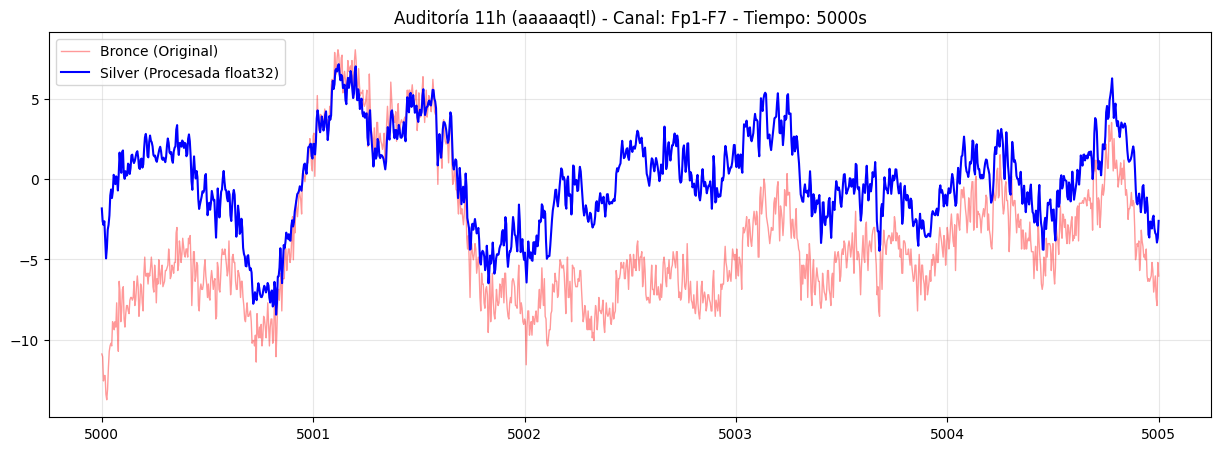

In [55]:
canal_test = "Fp1-F7"
sig_s = df_silver[canal_test].values
t_s = np.linspace(t_auditoria, t_auditoria + t_duracion, len(sig_s))

# El tiempo en raw_bip empieza en 0 tras el crop, así que le sumamos t_auditoria
sig_b, t_b = raw_bip.get_data(picks=canal_test, return_times=True)
t_b += t_auditoria 

plt.figure(figsize=(15, 5))
plt.plot(t_b, sig_b[0] * 1e6, color='red', alpha=0.4, label='Bronce (Original)', lw=1)
plt.plot(t_s, sig_s, color='blue', label='Silver (Procesada float32)', lw=1.5)

plt.title(f"Auditoría 11h (aaaaaqtl) - Canal: {canal_test} - Tiempo: {t_auditoria}s")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
# Ruta al archivo específico
path_parquet = r"D:\TUSZ_DataLake\03_TUSZ_Clean\300\s011_2014\aaaaaqtl_s011_t004.parquet"

# 1. Cargar el DataFrame
df = pd.read_parquet(path_parquet)

# 2. Cálculo basado en diferencias de tiempo (Delta T)
# Calculamos la diferencia de tiempo entre cada fila sucesiva
time_diffs = df['time'].diff().dropna()

# La frecuencia instantánea es 1 / delta_t
fs_series = 1 / time_diffs

print(f"📊 --- RESULTADOS DE AUDITORÍA EMPÍRICA ---")
print(f"Frecuencia Media Calculada: {fs_series.mean():.2f} Hz")
print(f"Desviación Estándar (Jitter): {time_diffs.std():.10f} s")
print(f"¿Es la frecuencia constante?: {'SÍ' if time_diffs.std() < 1e-6 else 'NO'}")

# 3. Validación por límites
print(f"\nFrecuencia Mínima detectada: {1/time_diffs.max():.2f} Hz")
print(f"Frecuencia Máxima detectada: {1/time_diffs.min():.2f} Hz")

# 4. Verificación por conteo global
duracion_total = df['time'].iloc[-1] - df['time'].iloc[0]
muestras_totales = len(df)
fs_global = muestras_totales / duracion_total

print(f"\n--- BALANCE FINAL ---")
print(f"Total Muestras: {muestras_totales}")
print(f"Tiempo Total:    {duracion_total:.4f} s")
print(f"Ratio Muestras/Segundo: {fs_global:.4f} Hz")

📊 --- RESULTADOS DE AUDITORÍA EMPÍRICA ---
Frecuencia Media Calculada: 250.00 Hz
Desviación Estándar (Jitter): 0.0000000000 s
¿Es la frecuencia constante?: SÍ

Frecuencia Mínima detectada: 250.00 Hz
Frecuencia Máxima detectada: 250.00 Hz

--- BALANCE FINAL ---
Total Muestras: 10335000
Tiempo Total:    41339.9960 s
Ratio Muestras/Segundo: 250.0000 Hz


# Sanity checks

In [9]:
# --- 1. SELECCIÓN ALEATORIA CONTROLADA ---
CLEAN_ROOT = Path(r"D:\TUSZ_DataLake\03_TUSZ_Clean")
RAW_ROOT = Path(r"D:\TUSZ_DataLake\01_Raw_Consolidated")

# Elegimos un parquet al azar para auditar
all_parquets = list(CLEAN_ROOT.rglob("*.parquet"))
sample_parquet = random.choice(all_parquets)

# Encontramos su origen (EDF) basándonos en el nombre del archivo
# El archivo EDF está en alguna subcarpeta de RAW_ROOT con el mismo nombre
sample_edf = next(RAW_ROOT.rglob(sample_parquet.stem + ".edf"))

print(f"🔍 Auditando Paciente/Sesión: {sample_parquet.parent.parent.name} / {sample_parquet.parent.name}")
print(f"📄 Archivo: {sample_parquet.name}")

# --- 2. CARGA DE DATOS ---
# Carga Bronce (Cruda)
raw_bronce = mne.io.read_raw_edf(sample_edf, preload=True, verbose=False)

# Normalización de nombres para poder aplicar el montaje Bipolar en el crudo
mapping = {ch: ch.replace('EEG ', '').replace('-REF', '').replace('-LE', '').strip() for ch in raw_bronce.ch_names}
corrections = {'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz'}
raw_bronce.rename_channels({k: corrections.get(v.upper(), v) for k, v in mapping.items()})

# Aplicamos montaje Bipolar al Crudo (Solo para comparar peras con peras)
pares = [('Fp1', 'F7'), ('F7', 'T3'), ('T3', 'T5'), ('T5', 'O1'), ('Fz', 'Cz'), ('Cz', 'Pz')]
valid_p = [p for p in pares if p[0] in raw_bronce.ch_names and p[1] in raw_bronce.ch_names]
raw_bronce_bip = mne.set_bipolar_reference(raw_bronce, anode=[p[0] for p in valid_p], 
                                           cathode=[p[1] for p in valid_p], drop_refs=True, verbose=False)

# Carga Silver (Procesada)
df_silver = pd.read_parquet(sample_parquet)

🔍 Auditando Paciente/Sesión: 515 / s004_2013
📄 Archivo: aaaaaoxr_s004_t004.parquet


In [10]:
def comparar_fidelidad(raw_b, df_s, canal, t_inicio=15, t_duracion=5):
    plt.figure(figsize=(15, 6))
    
    # Segmento Silver (250 Hz constante)
    fs_s = 250
    start_idx = int(t_inicio * fs_s)
    end_idx = int((t_inicio + t_duracion) * fs_s)
    
    if canal not in df_s.columns:
        print(f"❌ El canal {canal} no existe en el archivo Silver.")
        return

    sig_s = df_s[canal].iloc[start_idx:end_idx].values
    t_s = np.linspace(t_inicio, t_inicio + t_duracion, len(sig_s))
    
    # Segmento Bronce (Tiempo original del EDF)
    # MNE maneja su propia escala de tiempo, pedimos el segmento exacto
    try:
        sig_b, t_b = raw_b.get_data(picks=canal, tmin=t_inicio, tmax=t_inicio + t_duracion, return_times=True)
        
        # Graficamos Superposición
        plt.plot(t_b, sig_b[0] * 1e6, color='red', alpha=0.4, label='Bronce (Original: Bipolar sin filtros)', lw=1)
        plt.plot(t_s, sig_s, color='blue', label='Silver (Procesada: Resample + Filtros)', lw=1.5)
        
        plt.title(f"Test de Integridad de Señal - Canal: {canal}")
        plt.xlabel("Tiempo (segundos)")
        plt.ylabel("Amplitud (µV)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
    except Exception as e:
        print(f"❌ Error al extraer segmento del EDF: {e}")

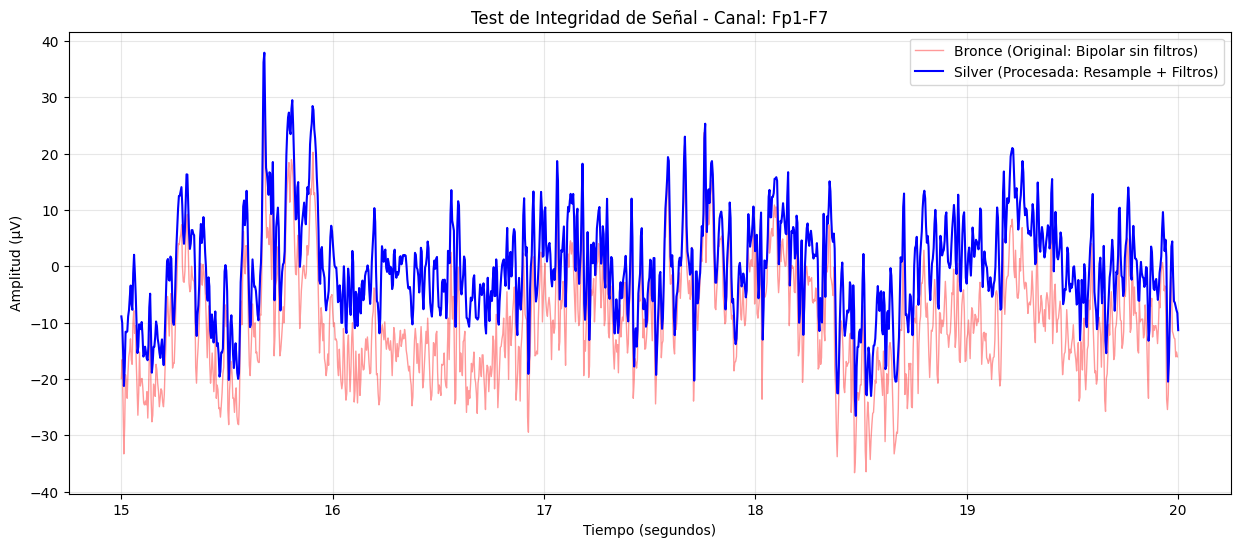

In [11]:
canal_test = [c for c in df_silver.columns if '-' in c][0]
comparar_fidelidad(raw_bronce_bip, df_silver, canal=canal_test)

In [12]:
ruta_pacientes = r"D:\TUSZ_DataLake\02_Metadata\metadata_patients.parquet"

# 2. Leer el archivo Parquet
df_pacientes = pd.read_parquet(ruta_pacientes)

# 3. Mostrar un resumen rápido
print(f"✅ Archivo cargado exitosamente.")
print(f"📊 Total de pacientes únicos: {len(df_pacientes)}")

# 4. Mostrar las primeras filas para verificar las 5 columnas
display(df_pacientes.head(10))

✅ Archivo cargado exitosamente.
📊 Total de pacientes únicos: 675


,patient_num_id,patient_id,original_split,age,gender,n_sessions,total_duration_sec,split_final
0,1,aaaaalpj,train,55,2,4,3015.0,0
1,2,aaaaaipg,train,38,2,3,4600.0,0
2,3,aaaaatvk,eval,28,2,3,9175.0,0
3,4,aaaaapkv,train,89,2,1,1238.0,0
4,5,aaaaalaw,train,28,2,1,1992.0,0
5,6,aaaaabgs,train,23,1,1,1226.0,0
6,7,aaaaasut,train,48,1,1,1294.0,0
7,8,aaaaahlk,train,27,1,3,3792.0,0
8,9,aaaaatgc,train,40,1,1,1515.0,0
9,10,aaaaanrp,train,82,1,1,1279.0,0


In [13]:
id_buscado = "aaaaaoxr"
resultado = df_pacientes[df_pacientes['patient_id'] == id_buscado]

# 6. Mostrar el resultado
if not resultado.empty:
    print(f"🔍 Se encontró información para el paciente: {id_buscado}")
    display(resultado)
else:
    print(f"⚠️ No se encontró ningún registro para el ID: {id_buscado}")

🔍 Se encontró información para el paciente: aaaaaoxr


,patient_num_id,patient_id,original_split,age,gender,n_sessions,total_duration_sec,split_final
514,515,aaaaaoxr,train,30,1,7,15458.0,1


In [20]:
ruta_sessions = r"D:\TUSZ_DataLake\02_Metadata\metadata_sessions.parquet"

# 2. Leer el archivo Parquet
df_sessions = pd.read_parquet(ruta_sessions)

# 3. Mostrar un resumen rápido
print(f"✅ Archivo cargado exitosamente.")
print(f"📊 Total de sesiones únicos: {len(df_sessions)}")

# 4. Mostrar las primeras filas para verificar las 5 columnas
display(df_sessions.head(10))

✅ Archivo cargado exitosamente.
📊 Total de sesiones únicos: 7364


,patient_num_id,session_id,partition_id,config_type,file_name,sfreq,n_channels,duration_sec,highpass,lowpass,date
0,604,s001,t000,01_tcp_ar,aaaaatth_s001_t000.edf,1000.0,30,1289.0,0.0,500.0,2015-01-01
1,3,s001,t000,01_tcp_ar,aaaaatvk_s001_t000.edf,256.0,34,1290.0,0.0,128.0,2015-01-01
2,3,s002,t001,01_tcp_ar,aaaaatvk_s002_t001.edf,256.0,34,301.0,0.0,128.0,2015-01-01
3,3,s002,t002,01_tcp_ar,aaaaatvk_s002_t002.edf,256.0,34,301.0,0.0,128.0,2015-01-01
4,3,s002,t004,01_tcp_ar,aaaaatvk_s002_t004.edf,256.0,34,301.0,0.0,128.0,2015-01-01
5,3,s002,t005,01_tcp_ar,aaaaatvk_s002_t005.edf,256.0,34,39.0,0.0,128.0,2015-01-01
6,3,s002,t007,01_tcp_ar,aaaaatvk_s002_t007.edf,256.0,34,155.0,0.0,128.0,2015-01-01
7,3,s002,t017,01_tcp_ar,aaaaatvk_s002_t017.edf,256.0,34,301.0,0.0,128.0,2015-01-01
8,3,s002,t019,01_tcp_ar,aaaaatvk_s002_t019.edf,256.0,34,301.0,0.0,128.0,2015-01-01
9,3,s002,t020,01_tcp_ar,aaaaatvk_s002_t020.edf,256.0,34,197.0,0.0,128.0,2015-01-01


In [22]:
resultado = df_sessions[df_sessions['patient_num_id'] == 515]

# 6. Mostrar el resultado
if not resultado.empty:
    print(f"🔍 Se encontró información para el paciente: {515}")
    display(resultado)
else:
    print(f"⚠️ No se encontró ningún registro para el ID: {515}")

🔍 Se encontró información para el paciente: 515


,patient_num_id,session_id,partition_id,config_type,file_name,sfreq,n_channels,duration_sec,highpass,lowpass,date
3088,515,s004,t000,01_tcp_ar,aaaaaoxr_s004_t000.edf,256.0,33,300.0,0.0,128.0,2013-01-01
3089,515,s004,t001,01_tcp_ar,aaaaaoxr_s004_t001.edf,256.0,33,601.0,0.0,128.0,2013-01-01
3090,515,s004,t002,01_tcp_ar,aaaaaoxr_s004_t002.edf,256.0,33,601.0,0.0,128.0,2013-01-01
3091,515,s004,t003,01_tcp_ar,aaaaaoxr_s004_t003.edf,256.0,33,300.0,0.0,128.0,2013-01-01
3092,515,s004,t004,01_tcp_ar,aaaaaoxr_s004_t004.edf,256.0,33,601.0,0.0,128.0,2013-01-01
3093,515,s004,t005,01_tcp_ar,aaaaaoxr_s004_t005.edf,256.0,33,300.0,0.0,128.0,2013-01-01
3094,515,s004,t006,01_tcp_ar,aaaaaoxr_s004_t006.edf,256.0,33,601.0,0.0,128.0,2013-01-01
3095,515,s004,t007,01_tcp_ar,aaaaaoxr_s004_t007.edf,256.0,33,300.0,0.0,128.0,2013-01-01
3096,515,s004,t008,01_tcp_ar,aaaaaoxr_s004_t008.edf,256.0,33,601.0,0.0,128.0,2013-01-01
3097,515,s004,t009,01_tcp_ar,aaaaaoxr_s004_t009.edf,256.0,33,300.0,0.0,128.0,2013-01-01


In [17]:
path_parquet = r"D:\TUSZ_DataLake\03_TUSZ_Clean\515\s004_2013\aaaaaoxr_s004_t004.parquet"

# Cargamos el archivo
df = pd.read_parquet(path_parquet)

print(f"=== DETALLE DE METADATA INTEGRADA (PACIENTE: aaaaaoxr) ===\n")

# 1. Metadata del Sujeto/Sesión
print(f"📌 ID Numérico del Paciente: {df['patient_num_id'].iloc[0]}")
print(f"📌 Fecha del Registro:      {df['date'].iloc[0]}")
print(f"📌 Duración Total:          {df['duration_sec'].iloc[0]} segundos")

print("\n--- Configuración de la Capa Silver (Pipeline) ---")
# 2. Metadata Técnica
print(f"⚙️ Filtros Aplicados:      {df['filter_configuration'].iloc[0]}")
print(f"⚙️ Rango de Frecuencias:    {df['bandpass_range_hz'].iloc[0]} Hz")
print(f"⚙️ Montaje Utilizado:       {df['montage_reference'].iloc[0]}")

# 3. Ver una muestra de los datos numéricos (las primeras 5 muestras)
print("\n--- Vista Previa de la Señal (Primeros canales) ---")
display(df[['time', 'Fp1-F7', 'F7-T3', 'Fp2-F8']].head())

=== DETALLE DE METADATA INTEGRADA (PACIENTE: aaaaaoxr) ===

📌 ID Numérico del Paciente: 515
📌 Fecha del Registro:      2013-01-01
📌 Duración Total:          601.0 segundos

--- Configuración de la Capa Silver (Pipeline) ---
⚙️ Filtros Aplicados:      Butterworth IIR 8th Order (Zero-Phase)
⚙️ Rango de Frecuencias:    0.5-80.0 Hz
⚙️ Montaje Utilizado:       Longitudinal Bipolar (Double Banana)

--- Vista Previa de la Señal (Primeros canales) ---


,time,Fp1-F7,F7-T3,Fp2-F8
0,0.000,0.335994,-0.866391,-0.352733
1,0.004,6.151628,-9.643531,-3.518187
2,0.008,10.153162,-10.142985,-2.546603
3,0.012,14.164264,-6.332250,1.207090
4,0.016,12.791793,-9.930666,1.890398


In [23]:
# Ruta al archivo específico
path_parquet = r"D:\TUSZ_DataLake\03_TUSZ_Clean\515\s004_2013\aaaaaoxr_s004_t004.parquet"

# 1. Cargar el DataFrame
df = pd.read_parquet(path_parquet)

# 2. Cálculo basado en diferencias de tiempo (Delta T)
# Calculamos la diferencia de tiempo entre cada fila sucesiva
time_diffs = df['time'].diff().dropna()

# La frecuencia instantánea es 1 / delta_t
fs_series = 1 / time_diffs

print(f"📊 --- RESULTADOS DE AUDITORÍA EMPÍRICA ---")
print(f"Frecuencia Media Calculada: {fs_series.mean():.2f} Hz")
print(f"Desviación Estándar (Jitter): {time_diffs.std():.10f} s")
print(f"¿Es la frecuencia constante?: {'SÍ' if time_diffs.std() < 1e-6 else 'NO'}")

# 3. Validación por límites
print(f"\nFrecuencia Mínima detectada: {1/time_diffs.max():.2f} Hz")
print(f"Frecuencia Máxima detectada: {1/time_diffs.min():.2f} Hz")

# 4. Verificación por conteo global
duracion_total = df['time'].iloc[-1] - df['time'].iloc[0]
muestras_totales = len(df)
fs_global = muestras_totales / duracion_total

print(f"\n--- BALANCE FINAL ---")
print(f"Total Muestras: {muestras_totales}")
print(f"Tiempo Total:    {duracion_total:.4f} s")
print(f"Ratio Muestras/Segundo: {fs_global:.4f} Hz")

📊 --- RESULTADOS DE AUDITORÍA EMPÍRICA ---
Frecuencia Media Calculada: 250.00 Hz
Desviación Estándar (Jitter): 0.0000000000 s
¿Es la frecuencia constante?: SÍ

Frecuencia Mínima detectada: 250.00 Hz
Frecuencia Máxima detectada: 250.00 Hz

--- BALANCE FINAL ---
Total Muestras: 150250
Tiempo Total:    600.9960 s
Ratio Muestras/Segundo: 250.0017 Hz
